# EDA univariada por variavel - Qualidade do ar no Rio de Janeiro

## Objetivo
Este notebook realiza EDA univariada para **poluentes** e **variaveis atmosfericas**.

## Estrutura da analise
Para cada variavel, o notebook mostra:
- estatisticas descritivas (media, mediana, p5, p95, desvio),
- distribuicao (histograma e boxplot),
- identificacao de extremos por IQR,
- serie temporal com medias moveis (7 e 30 dias),
- breve conclusao automatica.


## 1. Importacoes e configuracoes


In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, List
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
import seaborn as sns

URL_DADOS = (
    "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/"
    "refs/heads/Refactoring-And-Documentation/"
    "Data/IntermediaryData/MonitorAr/DailyQualiarRj/"
    "serie_diaria_qualidade_ar_rio_de_janeiro.parquet"
)

COLUNA_DATA = "data"
JANELA_MM_CURTA = 7
JANELA_MM_LONGA = 30

POLUENTES_CANDIDATOS: List[str] = [
    "pm10",
    "pm2_5",
    "o3",
    "no2",
    "so2",
    "co",
    "pts",
    "no",
    "nox",
]

VARIAVEIS_ATMOSFERICAS_CANDIDATAS: List[str] = [
    "temp",
    "tem",
    "ur",
    "chuva",
]

## 2. Carregamento da base


In [2]:
df_rj = pd.read_parquet(URL_DADOS)
df_rj[COLUNA_DATA] = pd.to_datetime(df_rj[COLUNA_DATA], errors="coerce").dt.normalize()
df_rj = df_rj.dropna(subset=[COLUNA_DATA]).sort_values(COLUNA_DATA).reset_index(drop=True)

print(f"Fonte usada: {URL_DADOS}")
print(f"Dimensao da base: {df_rj.shape[0]:,} linhas x {df_rj.shape[1]:,} colunas")
print(f"Periodo observado: {df_rj[COLUNA_DATA].min():%Y-%m-%d} ate {df_rj[COLUNA_DATA].max():%Y-%m-%d}")
display(df_rj.head())


Fonte usada: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/DailyQualiarRj/serie_diaria_qualidade_ar_rio_de_janeiro.parquet
Dimensao da base: 2,557 linhas x 12 colunas
Periodo observado: 2012-01-01 ate 2018-12-31


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva
0,2012-01-01,5.762,22.376,2.667,14.508,28.102,92.521,25.556,22.905,0.397,22.838,228.2
1,2012-01-02,25.347,29.317,2.290,8.158,54.670,95.074,22.264,13.924,0.311,14.965,371.0
2,2012-01-03,23.367,28.593,3.704,9.875,51.883,73.642,25.091,15.997,0.243,26.374,0.2
3,2012-01-04,28.645,36.209,3.177,14.823,64.833,72.631,26.083,23.245,0.267,35.924,0.4
4,2012-01-05,17.859,31.785,3.113,11.958,49.605,74.860,26.661,36.343,0.250,31.761,0.0


## 3. Definicao das variaveis da analise


In [3]:
colunas_numericas = df_rj.select_dtypes(include="number").columns.tolist()

variaveis_poluentes = [v for v in POLUENTES_CANDIDATOS if v in colunas_numericas]
variaveis_atmosfericas = [v for v in VARIAVEIS_ATMOSFERICAS_CANDIDATAS if v in colunas_numericas]
variaveis_analise = list(dict.fromkeys(variaveis_poluentes + variaveis_atmosfericas))

if not variaveis_analise:
    raise RuntimeError("Nenhuma variavel elegivel foi encontrada para EDA.")

mapa_grupo: Dict[str, str] = {}
for variavel in variaveis_poluentes:
    mapa_grupo[variavel] = "poluente"
for variavel in variaveis_atmosfericas:
    mapa_grupo[variavel] = "atmosferica"

# Base usada na EDA univariada.
df_eda = df_rj[[COLUNA_DATA] + variaveis_analise].copy()

tabela_variaveis = pd.DataFrame(
    {
        "variavel": variaveis_analise,
        "grupo": [mapa_grupo[v] for v in variaveis_analise],
    }
)

print(f"Total de variaveis na analise: {len(variaveis_analise)}")
print("Poluentes:", variaveis_poluentes)
print("Atmosfericas:", variaveis_atmosfericas)
display(tabela_variaveis)


Total de variaveis na analise: 11
Poluentes: ['pm10', 'pm2_5', 'o3', 'no2', 'so2', 'co', 'no', 'nox']
Atmosfericas: ['temp', 'ur', 'chuva']


,variavel,grupo
0,pm10,poluente
1,pm2_5,poluente
2,o3,poluente
3,no2,poluente
4,so2,poluente
5,co,poluente
6,no,poluente
7,nox,poluente
8,temp,atmosferica
9,ur,atmosferica


## 4. Funcoes auxiliares para analise por variavel


In [4]:
def calcular_estatisticas(serie: pd.Series) -> Dict[str, float]:
    serie_valida = serie.dropna()
    return {
        "n_validos": int(serie_valida.shape[0]),
        "n_nulos": int(serie.isna().sum()),
        "media": float(serie_valida.mean()),
        "mediana": float(serie_valida.median()),
        "p5": float(serie_valida.quantile(0.05)),
        "p95": float(serie_valida.quantile(0.95)),
        "desvio_padrao": float(serie_valida.std()),
        "minimo": float(serie_valida.min()),
        "maximo": float(serie_valida.max()),
    }


def calcular_extremos_iqr(serie: pd.Series) -> Dict[str, float]:
    serie_valida = serie.dropna()

    q1 = serie_valida.quantile(0.25)
    q3 = serie_valida.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_extremo = (serie < limite_inferior) | (serie > limite_superior)
    qtd_extremos = int(mascara_extremo.sum())
    pct_extremos = (qtd_extremos / int(serie_valida.shape[0])) if int(serie_valida.shape[0]) else np.nan

    return {
        "limite_inferior_iqr": float(limite_inferior),
        "limite_superior_iqr": float(limite_superior),
        "qtd_extremos": qtd_extremos,
        "pct_extremos": float(pct_extremos),
        "mascara_extremo": mascara_extremo,
    }


def plot_distribuicao_e_boxplot(serie: pd.Series, variavel: str) -> None:
    serie_valida = serie.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [3, 1]})

    sns.histplot(serie_valida, bins=35, kde=True, ax=axes[0], color="#2a9d8f")

    axes[0].set_title(f"Histograma - {variavel}")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Frequencia")
    sns.boxplot(y=serie_valida, ax=axes[1], color="#e9c46a")

    axes[1].set_title(f"Boxplot - {variavel}")
    axes[1].set_ylabel(variavel)

    plt.tight_layout()
    plt.show()


def plot_serie_temporal_mm(df: pd.DataFrame, variavel: str) -> pd.DataFrame:
    base_plot = df[[COLUNA_DATA, variavel]].copy().sort_values(COLUNA_DATA)

    base_plot[f"{variavel}_mm{JANELA_MM_CURTA}"] = (
        base_plot[variavel].rolling(window=JANELA_MM_CURTA, min_periods=3).mean()
    )
    base_plot[f"{variavel}_mm{JANELA_MM_LONGA}"] = (
        base_plot[variavel].rolling(window=JANELA_MM_LONGA, min_periods=7).mean()
    )

    plt.figure(figsize=(14, 4))
    plt.plot(base_plot[COLUNA_DATA], base_plot[variavel], color="#adb5bd", linewidth=1, label="serie diaria")
    plt.plot(
        base_plot[COLUNA_DATA],
        base_plot[f"{variavel}_mm{JANELA_MM_CURTA}"],
        color="#1d3557",
        linewidth=2,
        label=f"media movel {JANELA_MM_CURTA} dias",
    )
    plt.plot(
        base_plot[COLUNA_DATA],
        base_plot[f"{variavel}_mm{JANELA_MM_LONGA}"],
        color="#e76f51",
        linewidth=2,
        label=f"media movel {JANELA_MM_LONGA} dias",
    )

    plt.title(f"Serie temporal - {variavel}")
    plt.xlabel("Data")
    plt.ylabel(variavel)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    return base_plot

## 5. Secao por variavel (analise individual)

Cada variavel recebe um bloco proprio com estatisticas, distribuicao, extremos, serie temporal e conclusao.


In [5]:
resultados_por_variavel: Dict[str, Dict[str, object]] = {}
series_com_medias_moveis: Dict[str, pd.DataFrame] = {}


def executar_analise_variavel(variavel: str) -> None:
    if variavel not in variaveis_analise:
        display(Markdown(f"Variavel `{variavel}` nao encontrada na base atual."))
        return

    grupo = mapa_grupo[variavel]
    serie = df_eda[variavel]

    # 1) Estatisticas descritivas.
    stats = calcular_estatisticas(serie)
    tabela_stats = pd.DataFrame([stats]).round(3)
    display(Markdown("### Estatisticas descritivas"))
    display(tabela_stats)

    # 2) Distribuicao.
    display(Markdown("### Distribuicao (histograma e boxplot)"))
    plot_distribuicao_e_boxplot(serie, variavel)

    # 3) Extremos por IQR.
    extremos = calcular_extremos_iqr(serie)
    tabela_extremos = pd.DataFrame(
        [
            {
                "limite_inferior_iqr": extremos["limite_inferior_iqr"],
                "limite_superior_iqr": extremos["limite_superior_iqr"],
                "qtd_extremos": extremos["qtd_extremos"],
                "pct_extremos": extremos["pct_extremos"] * 100,
            }
        ]
    ).round(3)

    display(Markdown("### Identificacao de extremos"))
    display(tabela_extremos)

    amostra_extremos = (
        df_eda.loc[extremos["mascara_extremo"], [COLUNA_DATA, variavel]]
        .rename(columns={variavel: "valor"})
        .sort_values("valor", ascending=False)
        .head(5)
    )
    if not amostra_extremos.empty:
        display(Markdown("Amostra dos 5 maiores valores extremos:"))
        display(amostra_extremos)

    # 4) Serie temporal com medias moveis.
    display(Markdown("### Serie temporal com media movel (7 e 30 dias)"))
    base_mm = plot_serie_temporal_mm(df_eda, variavel)
    series_com_medias_moveis[variavel] = base_mm

    resultados_por_variavel[variavel] = {
        "grupo": grupo,
        "estatisticas": stats,
        "extremos": {
            "limite_inferior_iqr": extremos["limite_inferior_iqr"],
            "limite_superior_iqr": extremos["limite_superior_iqr"],
            "qtd_extremos": extremos["qtd_extremos"],
            "pct_extremos": extremos["pct_extremos"],
        },
    }


## 5.1 Variavel `pm10` (poluente)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2534,23,37.124,34.59,19.171,63.317,13.807,10.75,101.855


### Distribuicao (histograma e boxplot)

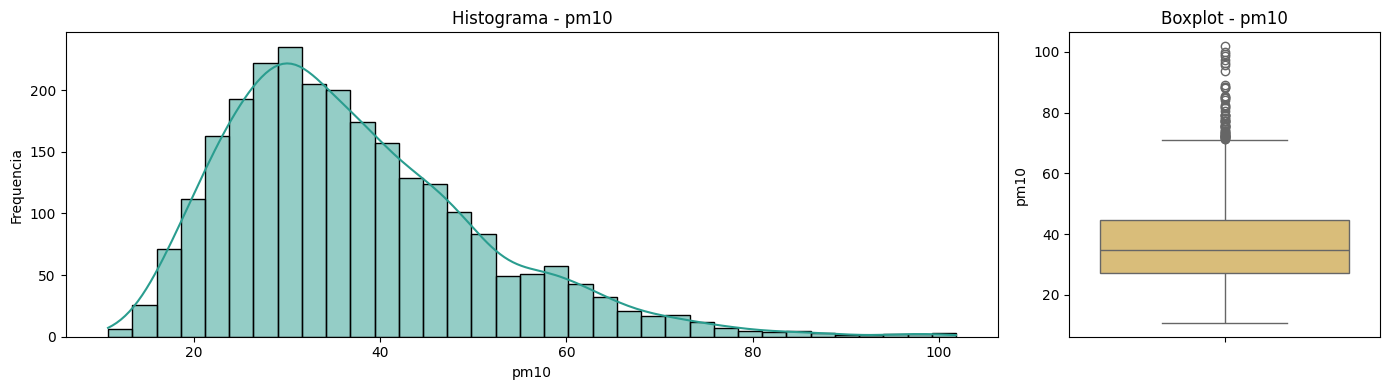

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,0.784,71.076,58,2.289


Amostra dos 5 maiores valores extremos:

,data,valor
579,2013-08-02,101.855
1362,2015-09-24,99.862
580,2013-08-03,99.371
25,2012-01-26,98.763
590,2013-08-13,97.354


### Serie temporal com media movel (7 e 30 dias)

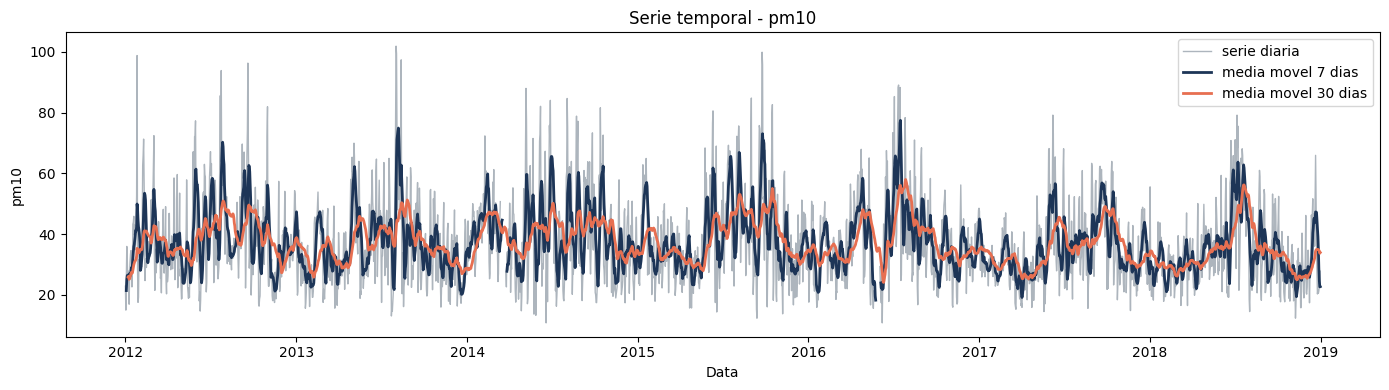

In [6]:
executar_analise_variavel("pm10")


### Breve analise dos resultados de `pm10`

- A serie possui 2534 valores validos e 23 nulos, indicando boa cobertura para a analise.
- A media (37.124) ficou acima da mediana (34.590), sugerindo assimetria a direita por causa de dias com concentracoes mais elevadas.
- O intervalo entre p5 e p95 foi de 19.171 a 63.317, enquanto o valor maximo atingiu 101.855.
- Pelo criterio do IQR, foram identificados 58 extremos (2.289%), com limite superior em 71.076.
- Os maiores picos extremos registrados ocorreram em 2013-08-02 (101.855), 2015-09-24 (99.862) e 2013-08-03 (99.371).
- Em conjunto, os resultados indicam comportamento predominantemente moderado, com episodios pontuais de alta concentracao que merecem acompanhamento.


## 5.2 Variavel `pm2_5` (poluente)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2516,41,17.462,14.938,6.325,38.005,10.344,0.333,91.007


### Distribuicao (histograma e boxplot)

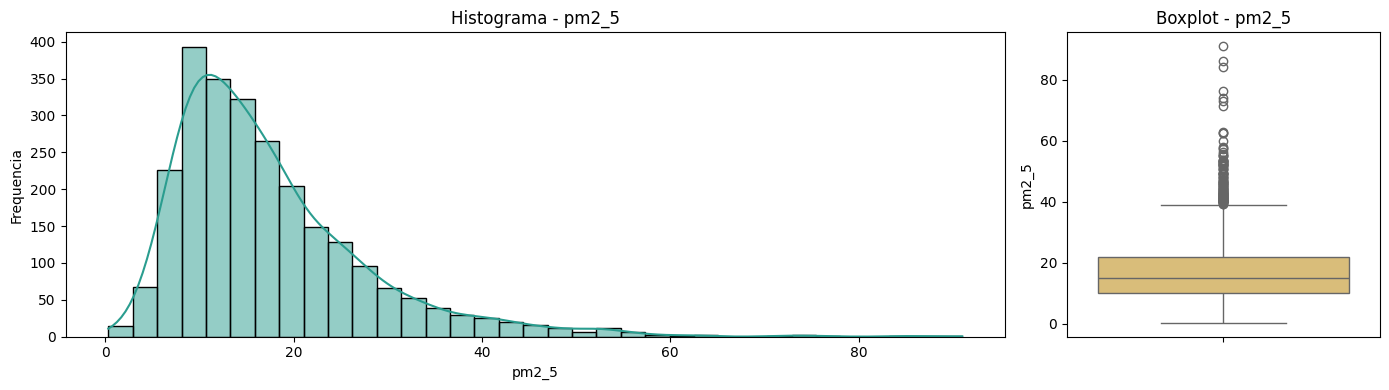

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,-7.206,39.231,112,4.452


Amostra dos 5 maiores valores extremos:

,data,valor
203,2012-07-22,91.007
579,2013-08-02,86.281
1645,2016-07-03,84.292
1630,2016-06-18,76.229
590,2013-08-13,74.167


### Serie temporal com media movel (7 e 30 dias)

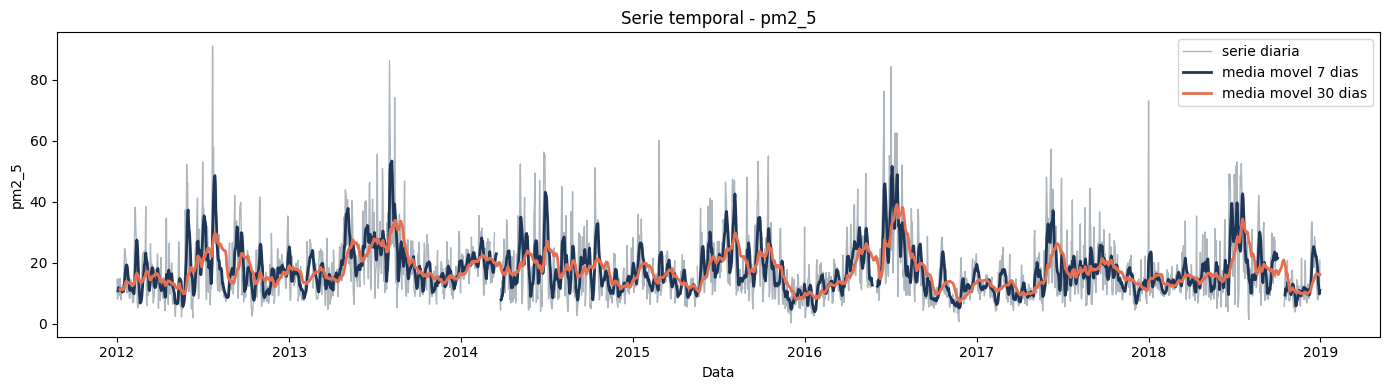

In [7]:
executar_analise_variavel("pm2_5")


### Breve analise dos resultados de `pm2_5`

- A serie possui 2516 valores validos e 41 nulos, com cobertura alta para avaliacao.
- A media (17.462) acima da mediana (14.938) sugere assimetria a direita.
- O intervalo p5-p95 ficou entre 6.325 e 38.005, com maximo de 91.007.
- Pelo criterio do IQR, foram identificados 112 extremos (4.452%), com limite superior em 39.231.
- Os maiores picos observados foram 2012-07-22 (91.007), 2013-08-02 (86.281) e 2016-07-03 (84.292).
- Em conjunto, os dados indicam niveis geralmente moderados, com eventos pontuais de concentracao elevada.


## 5.3 Variavel `o3` (poluente)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2534,23,30.136,28.986,14.336,50.386,11.1,4.687,80.184


### Distribuicao (histograma e boxplot)

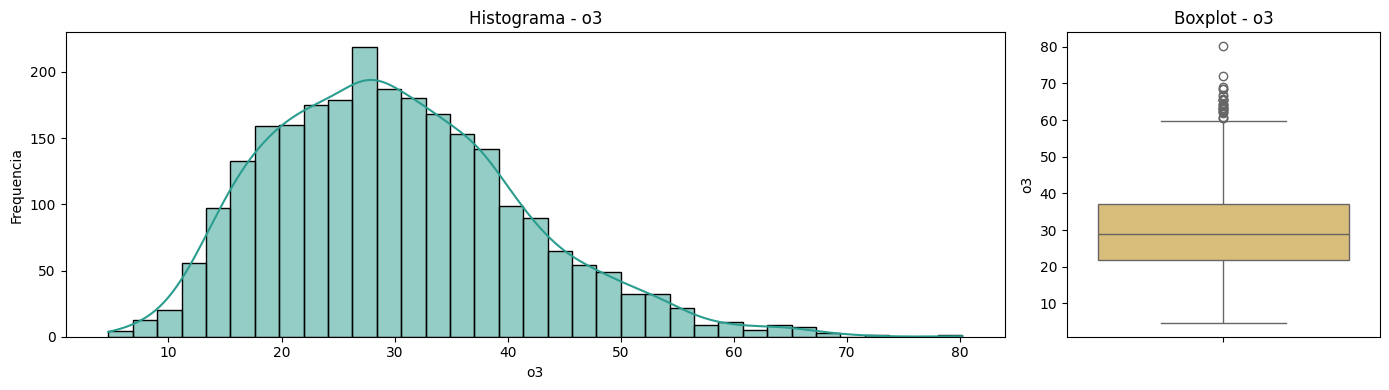

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,-0.839,59.722,28,1.105


Amostra dos 5 maiores valores extremos:

,data,valor
342,2012-12-08,80.184
364,2012-12-30,71.981
1107,2015-01-12,68.918
2547,2018-12-22,68.484
1827,2017-01-01,68.464


### Serie temporal com media movel (7 e 30 dias)

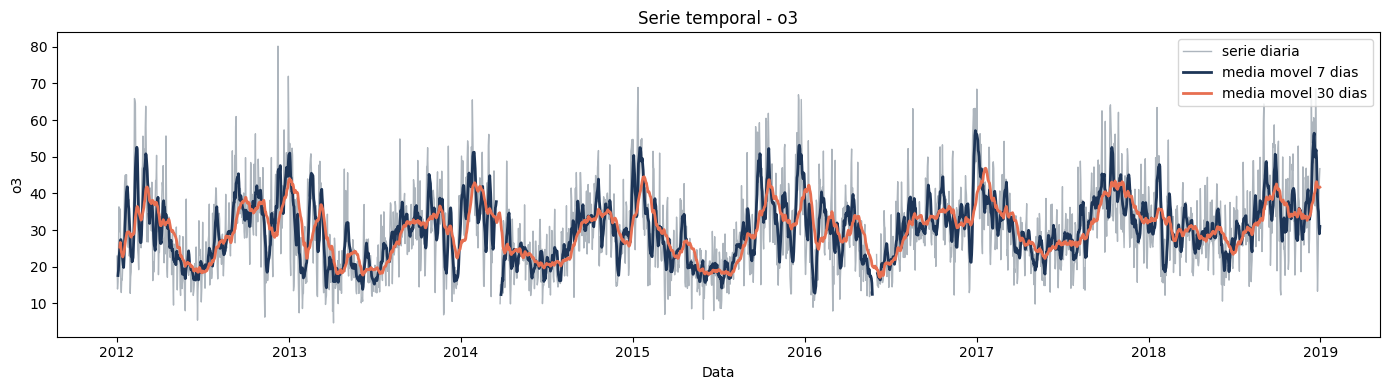

In [8]:
executar_analise_variavel("o3")


### Breve analise dos resultados de `o3`

- A serie possui 2534 valores validos e 23 nulos, mantendo boa representatividade.
- Media (30.136) e mediana (28.986) estao proximas, com leve assimetria a direita.
- O intervalo p5-p95 foi de 14.336 a 50.386, e o maximo alcancou 80.184.
- Pelo IQR, houve 28 extremos (1.105%), com limite superior em 59.722.
- Maiores picos: 2012-12-08 (80.184), 2012-12-30 (71.981) e 2015-01-12 (68.918).
- O comportamento geral parece relativamente estavel, com poucos episodios extremos.


## 5.4 Variavel `no2` (poluente)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2534,23,34.553,33.174,19.358,55.344,11.174,6.954,88.473


### Distribuicao (histograma e boxplot)

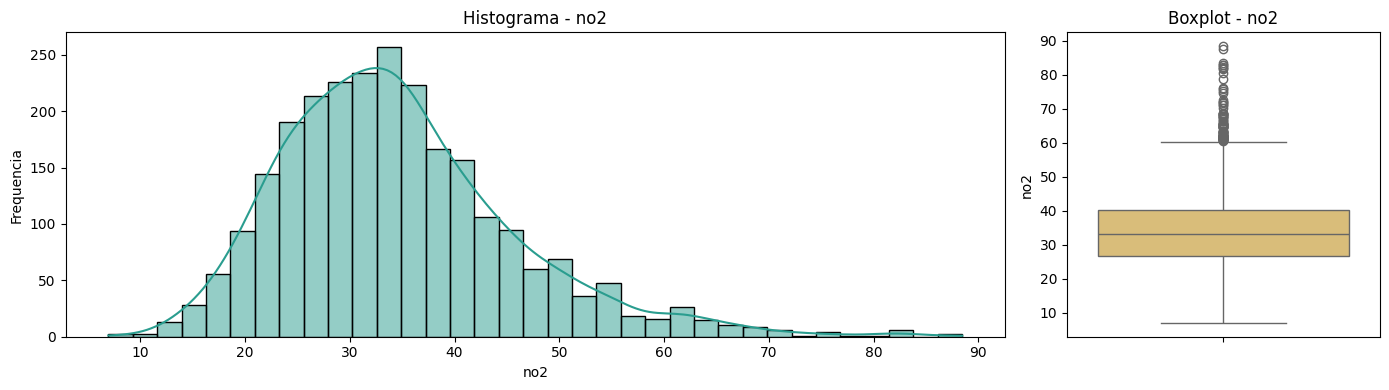

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,6.418,60.649,81,3.197


Amostra dos 5 maiores valores extremos:

,data,valor
946,2014-08-04,88.473
1984,2017-06-07,87.636
908,2014-06-27,83.434
954,2014-08-12,82.794
856,2014-05-06,82.786


### Serie temporal com media movel (7 e 30 dias)

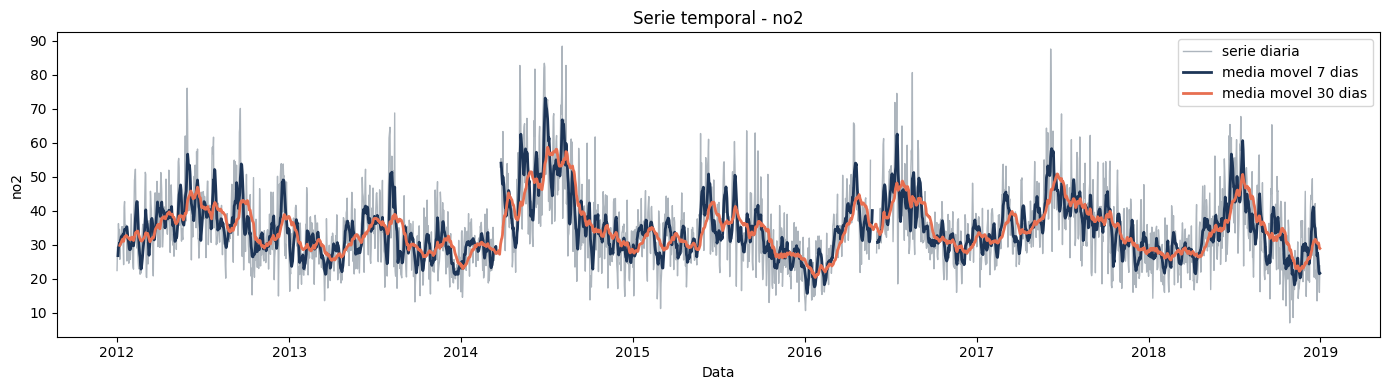

In [9]:
executar_analise_variavel("no2")


### Breve analise dos resultados de `no2`

- A serie apresenta 2534 valores validos e 23 nulos.
- A media (34.553) acima da mediana (33.174) indica distribuicao levemente assimetrica a direita.
- O intervalo p5-p95 ficou entre 19.358 e 55.344, com valor maximo de 88.473.
- Pelo IQR, foram detectados 81 extremos (3.197%), com limite superior em 60.649.
- Picos mais altos: 2014-08-04 (88.473), 2017-06-07 (87.636) e 2014-06-27 (83.434).
- Os resultados sugerem variabilidade moderada com alguns periodos de aumento mais intenso.


## 5.5 Variavel `so2` (poluente)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2534,23,4.44,3.915,1.287,9.334,2.591,0.228,20.389


### Distribuicao (histograma e boxplot)

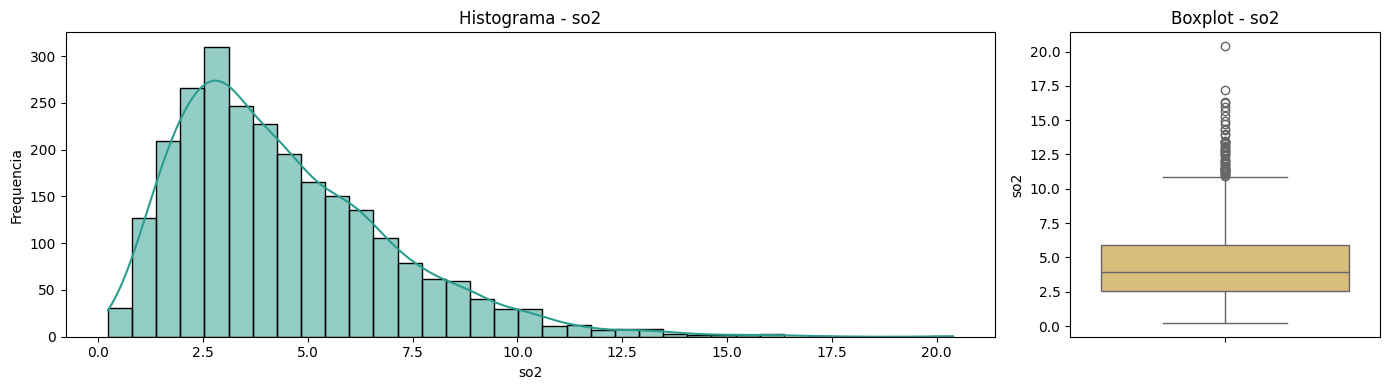

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,-2.479,10.893,54,2.131


Amostra dos 5 maiores valores extremos:

,data,valor
2374,2018-07-02,20.389
205,2012-07-24,17.214
1818,2016-12-23,16.299
2467,2018-10-03,16.224
61,2012-03-02,15.929


### Serie temporal com media movel (7 e 30 dias)

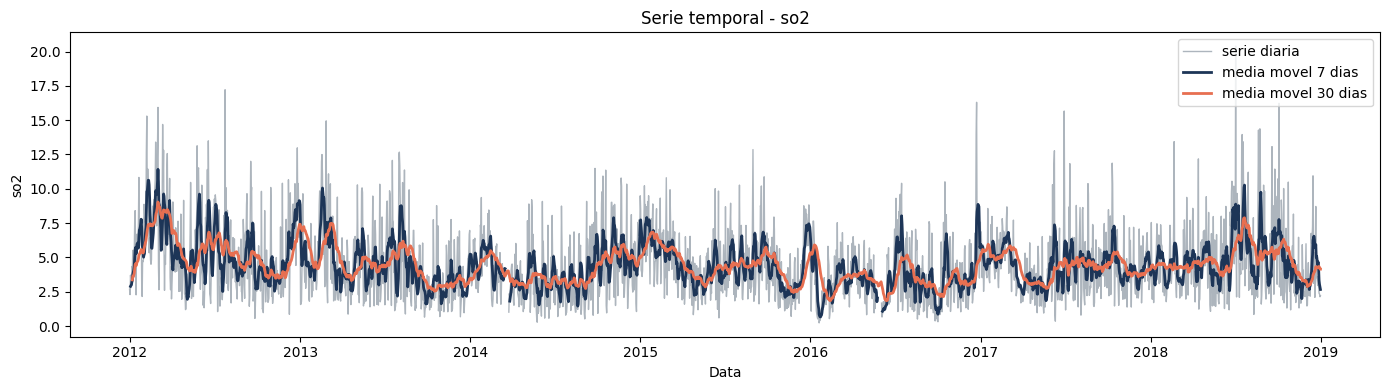

In [10]:
executar_analise_variavel("so2")


### Breve analise dos resultados de `so2`

- A serie tem 2534 valores validos e 23 nulos.
- Os niveis centrais sao baixos (media 4.440 e mediana 3.915), com dispersao reduzida (desvio 2.591).
- O intervalo p5-p95 foi de 1.287 a 9.334, enquanto o maximo atingiu 20.389.
- Pelo IQR, apareceram 54 extremos (2.131%), com limite superior de 10.893.
- Maiores picos: 2018-07-02 (20.389), 2012-07-24 (17.214) e 2016-12-23 (16.299).
- Em geral, o `so2` se manteve baixo, com poucos episodios de elevacao relevante.


## 5.6 Variavel `co` (poluente)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2534,23,0.344,0.321,0.193,0.59,0.126,0.084,1.203


### Distribuicao (histograma e boxplot)

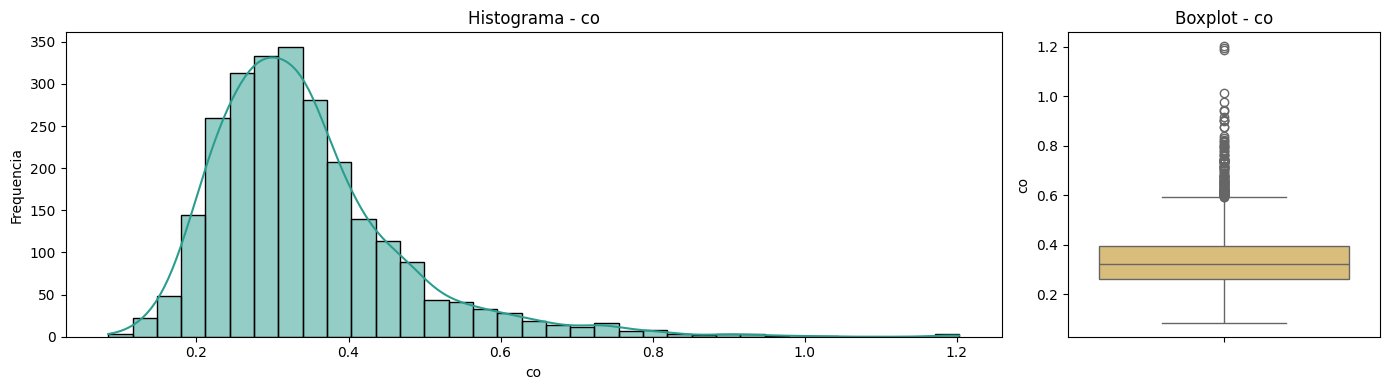

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,0.062,0.594,122,4.815


Amostra dos 5 maiores valores extremos:

,data,valor
580,2013-08-03,1.203
203,2012-07-22,1.195
579,2013-08-02,1.186
907,2014-06-26,1.013
888,2014-06-07,0.976


### Serie temporal com media movel (7 e 30 dias)

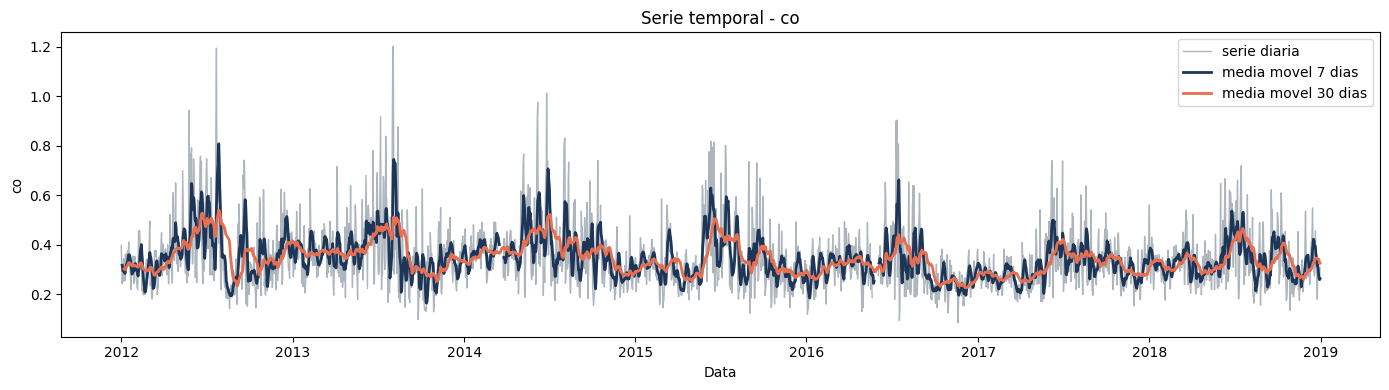

In [11]:
executar_analise_variavel("co")


### Breve analise dos resultados de `co`

- A serie possui 2534 valores validos e 23 nulos.
- A media (0.344) e mediana (0.321) indicam concentracoes tipicamente baixas.
- O intervalo p5-p95 foi de 0.193 a 0.590, com maximo de 1.203.
- Pelo IQR, foram identificados 122 extremos (4.815%), com limite superior em 0.594.
- Principais picos: 2013-08-03 (1.203), 2012-07-22 (1.195) e 2013-08-02 (1.186).
- O `co` mostra base baixa, mas com frequencia nao desprezivel de picos acima do padrao.


## 5.7 Variavel `no` (poluente)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2534,23,16.332,13.374,4.825,38.64,11.093,1.606,88.887


### Distribuicao (histograma e boxplot)

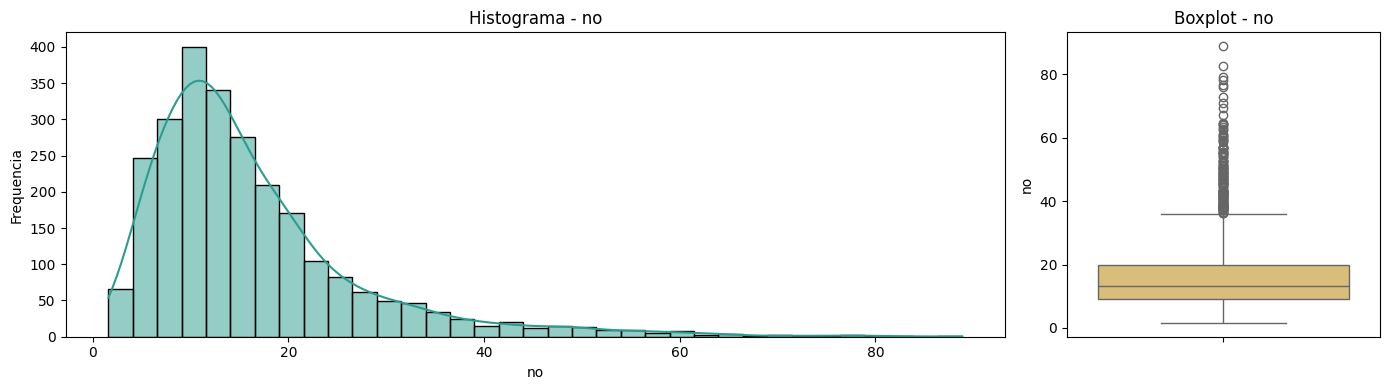

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,-6.833,36.036,151,5.959


Amostra dos 5 maiores valores extremos:

,data,valor
145,2012-05-25,88.887
907,2014-06-26,82.762
202,2012-07-21,79.047
2388,2018-07-16,78.185
579,2013-08-02,76.543


### Serie temporal com media movel (7 e 30 dias)

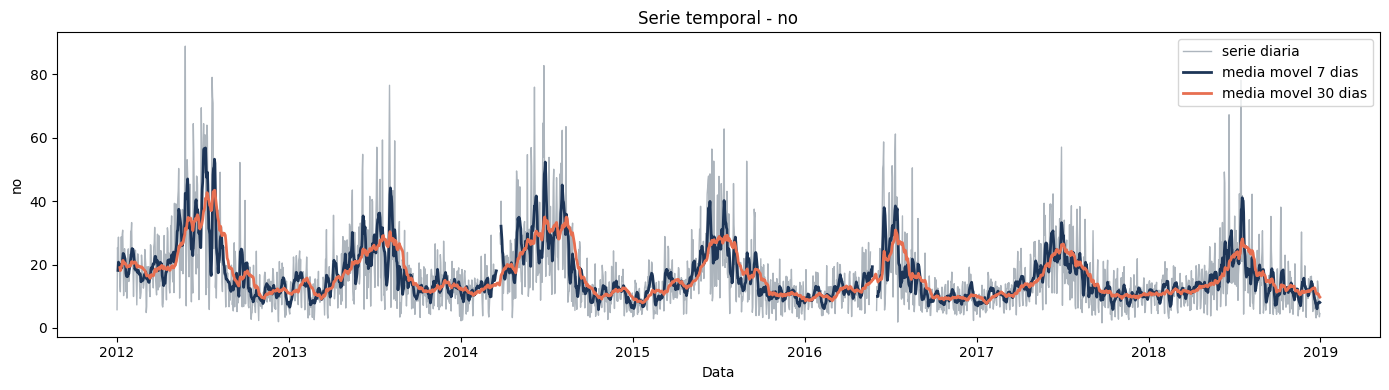

In [12]:
executar_analise_variavel("no")


### Breve analise dos resultados de `no`

- A serie apresenta 2534 valores validos e 23 nulos.
- A diferenca entre media (16.332) e mediana (13.374) sugere assimetria a direita mais marcada.
- O intervalo p5-p95 ficou entre 4.825 e 38.640, com maximo de 88.887.
- Pelo IQR, houve 151 extremos (5.959%), com limite superior em 36.036.
- Maiores picos: 2012-05-25 (88.887), 2014-06-26 (82.762) e 2012-07-21 (79.047).
- Os resultados apontam alta sensibilidade a eventos de curto prazo e variacao elevada nos extremos.


## 5.8 Variavel `nox` (poluente)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2534,23,50.876,46.854,26.174,91.368,20.35,11.779,163.708


### Distribuicao (histograma e boxplot)

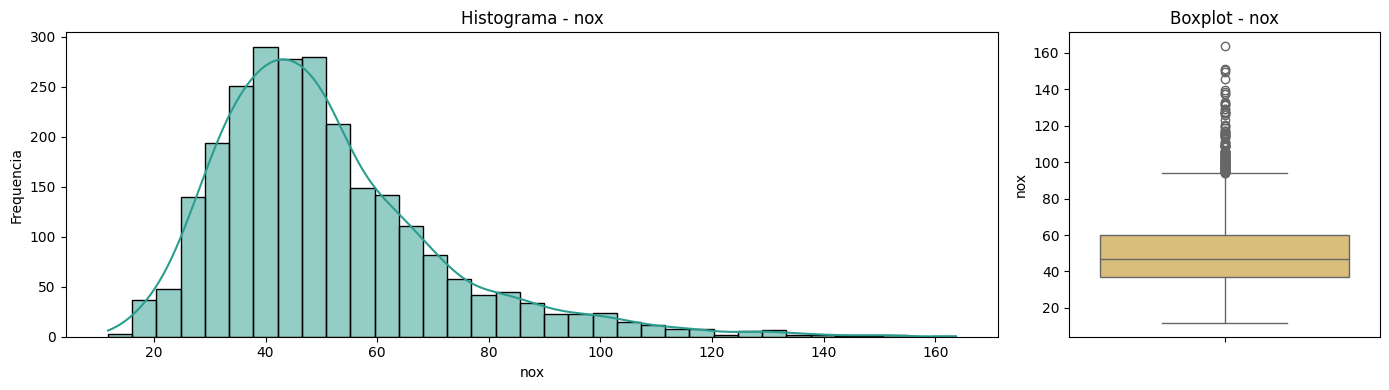

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,2.936,94.172,115,4.538


Amostra dos 5 maiores valores extremos:

,data,valor
907,2014-06-26,163.708
145,2012-05-25,150.909
946,2014-08-04,150.823
954,2014-08-12,149.457
2388,2018-07-16,145.945


### Serie temporal com media movel (7 e 30 dias)

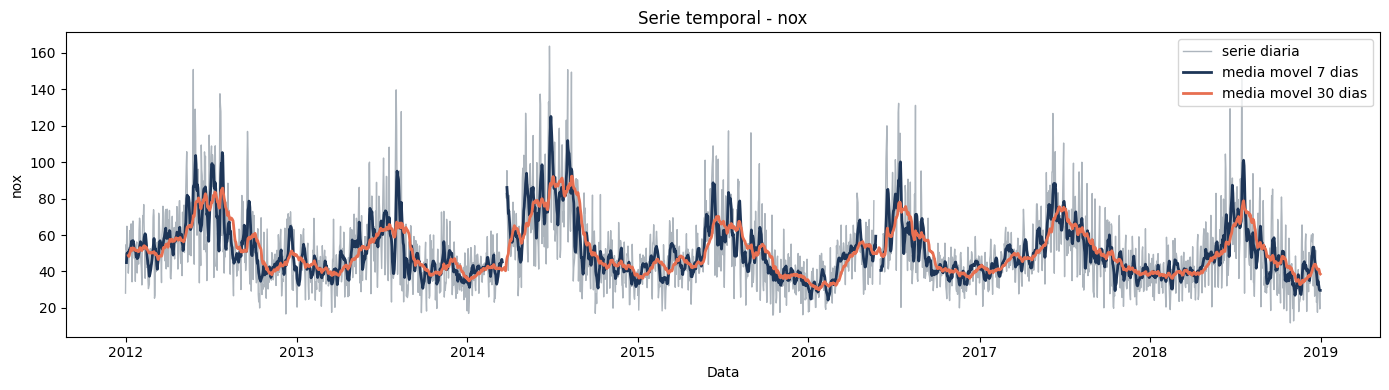

In [13]:
executar_analise_variavel("nox")


### Breve analise dos resultados de `nox`

- A serie possui 2534 valores validos e 23 nulos.
- Media (50.876) acima da mediana (46.854) indica assimetria a direita.
- O intervalo p5-p95 foi de 26.174 a 91.368, com maximo de 163.708 e desvio de 20.350.
- Pelo IQR, foram encontrados 115 extremos (4.538%), com limite superior em 94.172.
- Picos maximos: 2014-06-26 (163.708), 2012-05-25 (150.909) e 2014-08-04 (150.823).
- O `nox` apresenta maior amplitude e volatilidade, com episodios extremos mais pronunciados.


## 5.9 Variavel `temp` (atmosferica)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2534,23,26.032,25.818,20.86,31.579,3.302,15.897,35.313


### Distribuicao (histograma e boxplot)

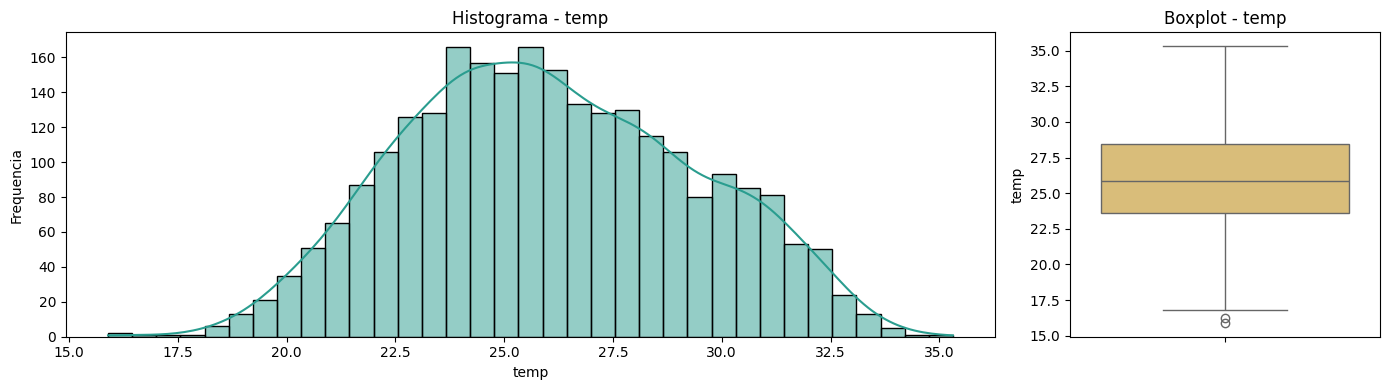

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,16.334,35.696,2,0.079


Amostra dos 5 maiores valores extremos:

,data,valor
571,2013-07-25,16.211
570,2013-07-24,15.897


### Serie temporal com media movel (7 e 30 dias)

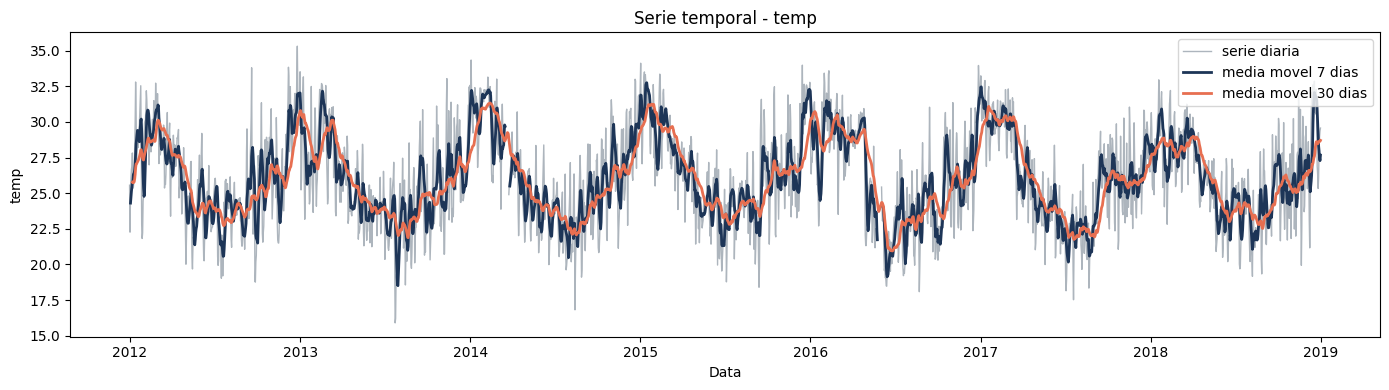

In [14]:
executar_analise_variavel("temp")


### Breve analise dos resultados de `temp`

- A serie tem 2534 valores validos e 23 nulos.
- Media (26.032) e mediana (25.818) estao muito proximas, indicando distribuicao central estavel.
- O intervalo p5-p95 ficou entre 20.860 e 31.579, com maximo de 35.313.
- Pelo IQR, apenas 2 extremos foram identificados (0.079%), com limite superior em 35.696.
- Na amostra de extremos, destacam-se 2013-07-25 (16.211) e 2013-07-24 (15.897), sugerindo cauda inferior mais critica.
- Em geral, a variavel `temp` apresenta comportamento bastante regular ao longo da serie.


## 5.10 Variavel `ur` (atmosferica)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2534,23,69.889,69.986,52.596,87.584,10.086,40.722,97.247


### Distribuicao (histograma e boxplot)

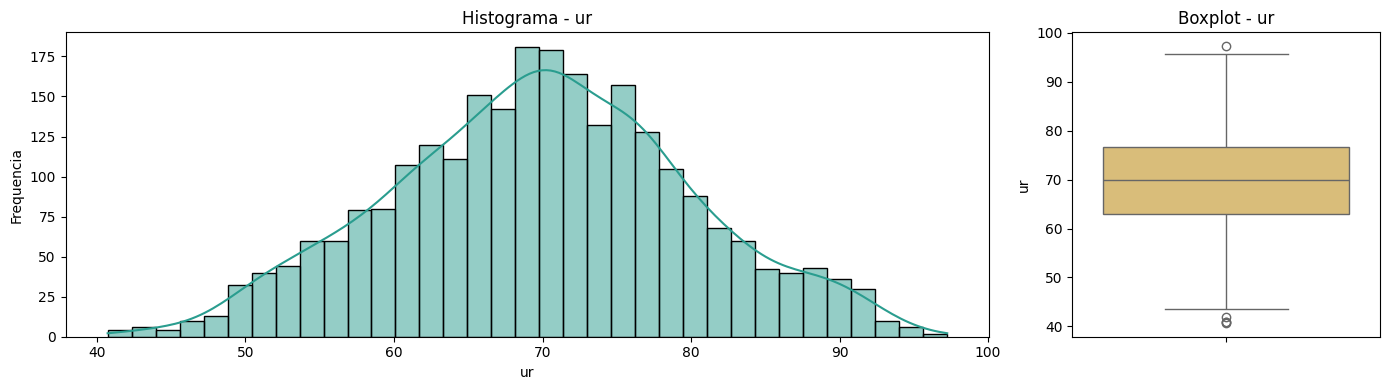

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,42.694,96.884,5,0.197


Amostra dos 5 maiores valores extremos:

,data,valor
2503,2018-11-08,97.247
262,2012-09-19,41.901
967,2014-08-25,40.921
1717,2016-09-13,40.911
1105,2015-01-10,40.722


### Serie temporal com media movel (7 e 30 dias)

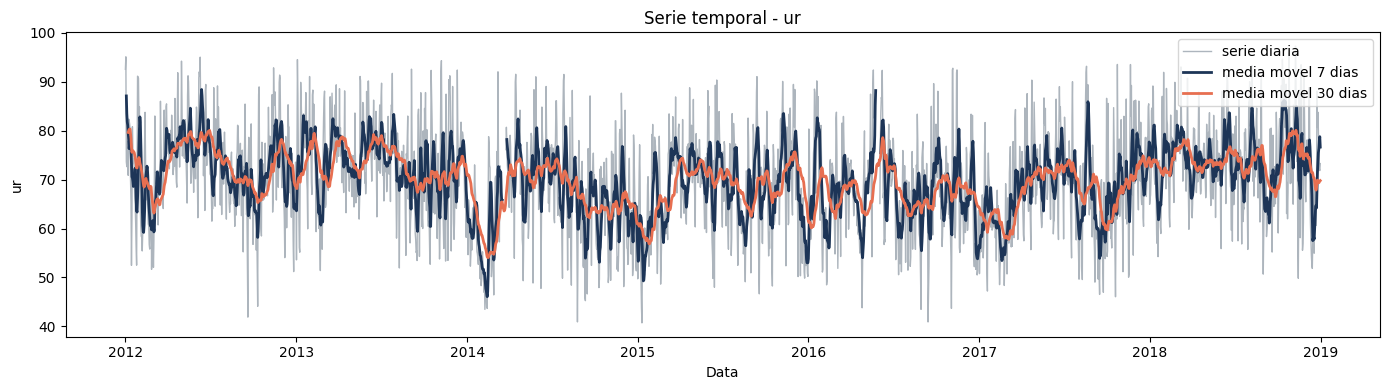

In [15]:
executar_analise_variavel("ur")


### Breve analise dos resultados de `ur`

- A serie apresenta 2534 valores validos e 23 nulos.
- Media (69.889) e mediana (69.986) praticamente coincidem, sugerindo distribuicao equilibrada no centro.
- O intervalo p5-p95 foi de 52.596 a 87.584, com minimo de 40.722 e maximo de 97.247.
- Pelo IQR, foram observados 5 extremos (0.197%), com limite superior em 96.884.
- A amostra de extremos inclui 2018-11-08 (97.247), 2012-09-19 (41.901) e 2014-08-25 (40.921), indicando ocorrencias raras tanto em alta quanto em baixa.
- A umidade relativa se manteve estavel na maior parte do periodo, com poucas anomalias.


## 5.11 Variavel `chuva` (atmosferica)


### Estatisticas descritivas

,n_validos,n_nulos,media,mediana,p5,p95,desvio_padrao,minimo,maximo
0,2557,0,23.026,0.2,0.0,140.36,57.337,0.0,807.0


### Distribuicao (histograma e boxplot)

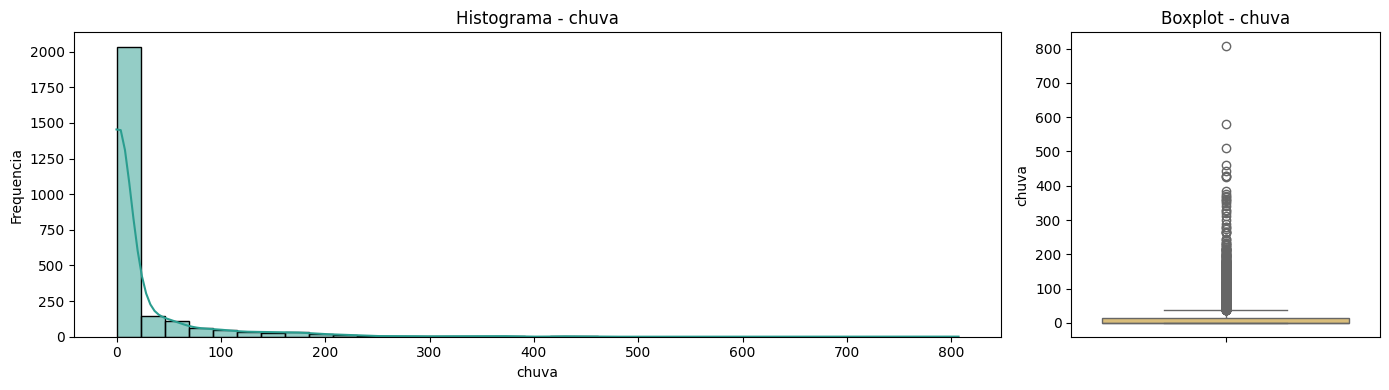

### Identificacao de extremos

,limite_inferior_iqr,limite_superior_iqr,qtd_extremos,pct_extremos
0,-22.2,37.0,429,16.777


Amostra dos 5 maiores valores extremos:

,data,valor
710,2013-12-11,807.0
368,2013-01-03,581.0
1176,2015-03-22,509.6
1520,2016-02-29,459.0
382,2013-01-17,443.4


### Serie temporal com media movel (7 e 30 dias)

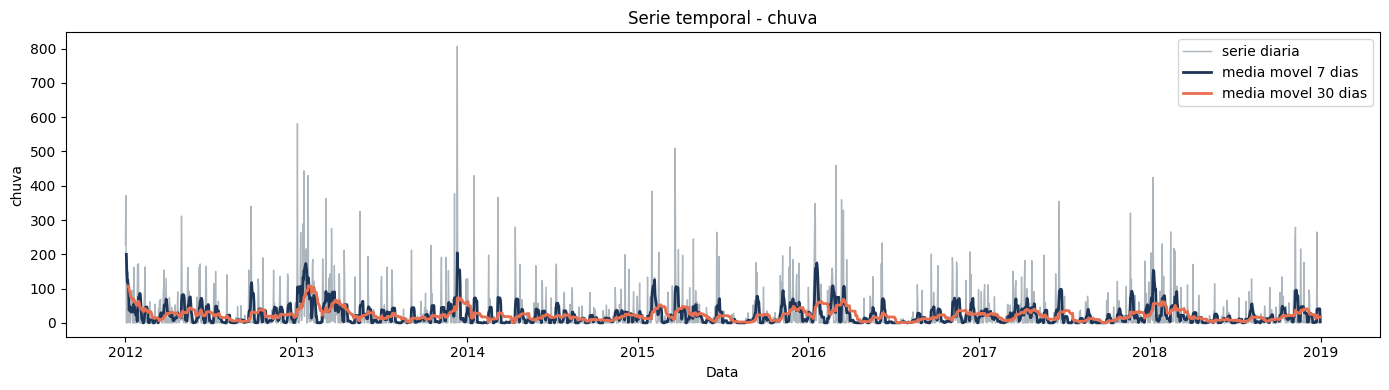

In [16]:
executar_analise_variavel("chuva")


### Breve analise dos resultados de `chuva`

- A serie possui 2557 valores validos e nenhum valor nulo.
- A media (23.026) muito acima da mediana (0.200) evidencia forte assimetria, com muitos dias secos e poucos eventos intensos.
- O intervalo p5-p95 foi de 0.000 a 140.360, e o maximo chegou a 807.000.
- Pelo IQR, foram detectados 429 extremos (16.777%), com limite superior em 37.000.
- Maiores picos: 2013-12-11 (807.000), 2013-01-03 (581.000) e 2015-03-22 (509.600).
- O padrao de `chuva` e altamente intermitente, com concentracao de eventos extremos em poucos dias.
